In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dispersion
import orbitcreation
import conductivity
from makesigmalist import makelist_parallel
from time import time

# 22 percent sample

In [26]:
thetalist = np.linspace(-14,99,80)

res_z = 20
res_xy = 100

fixedparams = [190e-3,-0.134,0.067,0.805] #T,T1multvalue,T11multvalue,mumultvalue

def create_rhozz(phi,Bmag,params):
    dispersionInstance = dispersion.LSCOdispersion(T=fixedparams[0],T1multvalue=fixedparams[1],T11multvalue=fixedparams[2],Tzmultvalue=params[0],mumultvalue=fixedparams[3])

    #0.22 params
    #T= 190e-3,T1multvalue=-0.134,T11multvalue=0.067,Tzmultvalue=Tzmultvalue,mumultvalue=0.805

    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    calculated_doping = FSorbitsInstance.calculateDoping()
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}. Doping = {calculated_doping}%")

    def create_rhozz(phi,Bmag):
        phi_rad = np.deg2rad(phi)

        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=params[1],invtau_aniso=params[2])
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum

        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]

        return rhozzlist
    
    rhozzlist = create_rhozz(phi=phi,Bmag=Bmag)

    return rhozzlist

def calc_rhoxx_zeroB(params):
    dispersionInstance = dispersion.LSCOdispersion(T=fixedparams[0],T1multvalue=fixedparams[1],T11multvalue=fixedparams[2],Tzmultvalue=params[0],mumultvalue=fixedparams[3])

    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)

    conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=params[1],invtau_aniso=params[2])
    conductivityInstance.createAmatrix_Bindependent()

    conductivityInstance.createAmatrix_Bdependent(0)
    conductivityInstance.createAlpha()
    conductivityInstance.createSigma()

    sigma = conductivityInstance.sigma
    rhoxx = np.linalg.inv(sigma)[0,0]*10e-5

    return rhoxx

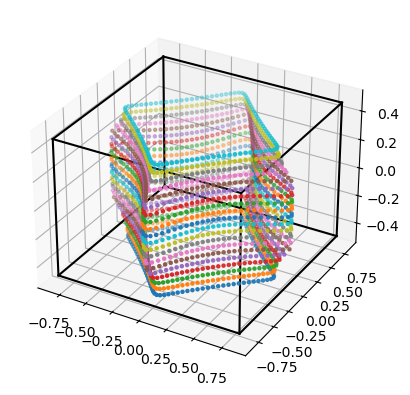

Time taken to create Fermi Surface = 0.06007266044616699


In [27]:
dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.134,T11multvalue=0.067,Tzmultvalue=0.079,mumultvalue=0.805)
FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
starttime = time()
FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
endtime = time()
FSorbitsInstance.plotpoints()
print(f"Time taken to create Fermi Surface = {endtime - starttime}")

In [ ]:
Tlist = [20,25,30,35]
paramslist = []

for temp in Tlist:
    filename = f"fit_logs_fixTz_at35K/fit_logs_22perc_{temp}K.txt"
    cost,Tzmultvalue,invtau_iso,invtau_aniso = np.loadtxt(filename,unpack=True,skiprows=5,delimiter=",")
    min_index = np.argmin(cost)
    paramslist.append((Tzmultvalue[min_index],invtau_iso[min_index],invtau_aniso[min_index]))
    print((Tzmultvalue[min_index],invtau_iso[min_index],invtau_aniso[min_index]))

rhozzlist0 = []
rhozzlist45 = []
data_rhozz0list = []
data_rhozz45list = []
data_theta0list = []
data_theta45list = []

for T,params in zip(Tlist,paramslist):

    #load data
    data_theta0,data_rhozz0 = np.loadtxt(f"data/2601C/2601C_phi0_T{T}K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta0list.append(data_theta0)
    data_rhozz0list.append(data_rhozz0)

    data_theta45,data_rhozz45 = np.loadtxt(f"data/2601C/2601C_phi45_T{T}K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta45list.append(data_theta45)
    data_rhozz45list.append(data_rhozz45)

    #generate data
    rhozzlist0.append(create_rhozz(phi=0,Bmag=45,params=params))
    rhozzlist45.append(create_rhozz(phi=45,Bmag=45,params=params))

(np.float64(0.07941809516397977), np.float64(9.987011274570893), np.float64(180.12794464321343))
(np.float64(0.07941809516397977), np.float64(11.63986687095777), np.float64(181.39081265472686))
(np.float64(0.07941809516397977), np.float64(12.952701443010504), np.float64(185.0321744046277))
(np.float64(0.07941839419796835), np.float64(14.043939769588011), np.float64(189.85486969743133))
Time taken to create Fermi Surface = 0.060553550720214844. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.0042455196380615234
Time taken to create Fermi Surface = 0.06628823280334473. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.020995616912841797
Time taken to create Fermi Surface = 0.05920743942260742. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.005697727203369141
Time taken to create Fermi Surface = 0.06451606750488281. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.0058300495147705

<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not w

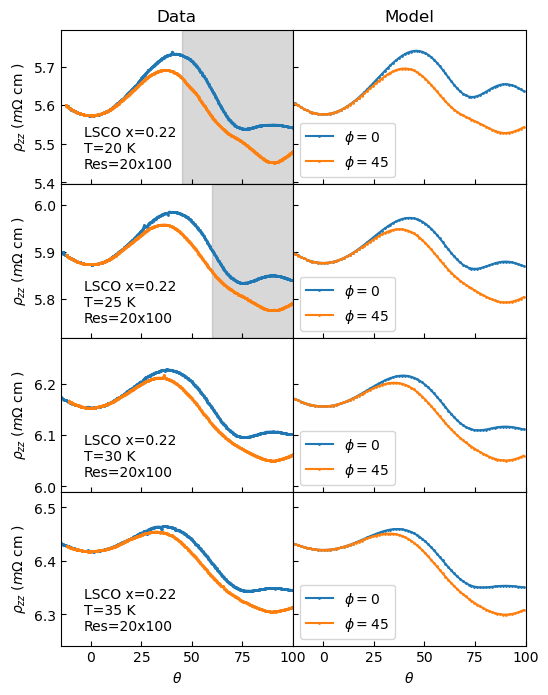

In [29]:
fig,axes = plt.subplots(nrows=4,ncols=2,figsize=(6,8),sharex=True)

for T,row,params,data_theta0,data_theta45,data_rhozz0,data_rhozz45,rhozz0,rhozz45 in zip(Tlist,axes,paramslist,data_theta0list,data_theta45list,data_rhozz0list,data_rhozz45list,rhozzlist0,rhozzlist45):

    row[1].plot(thetalist,rhozz0,ls="-",marker="o",ms=1,label=f"$\phi=0$")
    row[1].plot(thetalist,rhozz45,ls="-",marker="o",ms=1,label=f"$\phi=45$")
    row[0].plot(data_theta0,data_rhozz0,ls="-",marker="o",ms=1,label=f"$\phi=0$")
    row[0].plot(data_theta45,data_rhozz45,ls="-",marker="o",ms=1,label=f"$\phi=45$")
    row[0].set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )")
    row[0].text(0.1,0.1,f"LSCO x=0.22\nT={T} K\nRes={res_z}x{res_xy}",fontsize=10, transform=row[0].transAxes)
    row[1].legend()
    row[1].set_yticklabels([])

    for column in row:
        column.set_ylim(np.min(data_rhozz45)*0.99,np.max(data_rhozz0)*1.01)
        column.tick_params(direction='in')

axes[3,0].set_xlabel(r'$\theta$')
axes[3,1].set_xlabel(r'$\theta$')
axes[0,0].set_title("Data")
axes[0,1].set_title("Model")

axes[0,0].axvspan(45, 120, alpha=0.3, color='gray')
axes[1,0].axvspan(60, 120, alpha=0.3, color='gray')
axes[0,0].set_xlim(-15,100)

#make vspace 0
plt.subplots_adjust(hspace=0.0,wspace=0.0)

plt.show()

Text(0.1, 0.8, 'LSCO x=0.22\nRes=20x100')

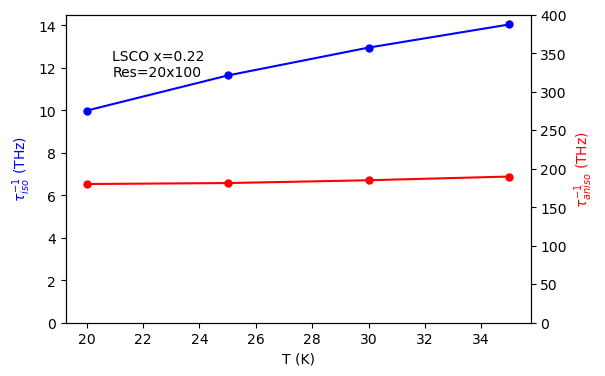

In [30]:
#plotting scattering rates
fig,axes = plt.subplots(figsize=(6,4))
axes2 = axes.twinx()

invtau_iso_list = [params[1] for params in paramslist]
invtau_aniso_list = [params[2] for params in paramslist]

axes.plot(Tlist,invtau_iso_list,ls="-",marker="o",ms=5,label=r"$\tau_{iso}^{-1}$",color="blue")
axes.set_ylabel(r"$\tau_{iso}^{-1}$ (THz)",color="blue")
axes.set_ylim(0,14.5)

axes2.plot(Tlist,invtau_aniso_list,ls="-",marker="o",ms=5,label=r"$\tau_{aniso}^{-1}$",color="red")
axes2.set_ylabel(r"$\tau_{aniso}^{-1}$ (THz)",color="red")
axes.set_xlabel("T (K)")
axes2.set_ylim(0,400)

axes.text(0.1,0.8,f"LSCO x=0.22\nRes={res_z}x{res_xy}",fontsize=10, transform=axes.transAxes)

<>:8: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
<>:8: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
C:\Users\Sahas\AppData\Local\Temp\ipykernel_41844\3667153211.py:8: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
  data_Trhoxx,data_rhoxx = np.loadtxt(f"ppms data\LSCO 2601D and E_Resistivity vs T_2K to 300K.dat",unpack=True,skiprows=31,delimiter=",",usecols=(3,6))


[np.float64(18.99466391304919), np.float64(21.739603636909944), np.float64(23.93052795721443), np.float64(25.76850094770321)]


(0.0, 50.0)

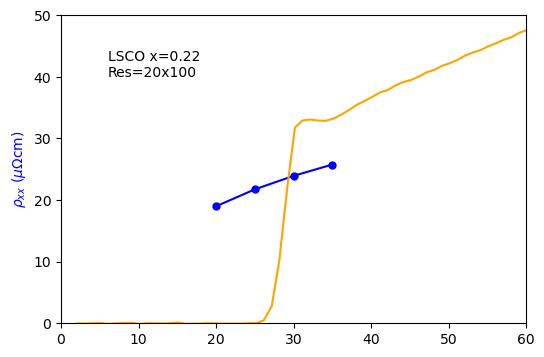

In [40]:
#plotting rhoxx
fig,axes = plt.subplots(figsize=(6,4))

rhoxx_list = [calc_rhoxx_zeroB(params)*1e3 for params in paramslist]
print(rhoxx_list)

#load rhoxx data
data_Trhoxx,data_rhoxx = np.loadtxt(f"ppms data\LSCO 2601D and E_Resistivity vs T_2K to 300K.dat",unpack=True,skiprows=31,delimiter=",",usecols=(3,6))

axes.plot(Tlist,rhoxx_list,ls="-",marker="o",ms=5,label=r"$\rho_{xx}$",color="blue")
axes.plot(data_Trhoxx,data_rhoxx*1e6,ls="-",label="Data",color="orange")
axes.set_ylabel(r"$\rho_{xx}$ ($\mu\Omega$cm)",color="blue")

axes.text(0.1,0.8,f"LSCO x=0.22\nRes={res_z}x{res_xy}",fontsize=10, transform=axes.transAxes)

axes.set_xlim(0,60)
axes.set_ylim(0,50)

# 24 percent sample

In [20]:
thetalist = np.linspace(-14,99,80)

res_z = 20
res_xy = 100

fixedparams = [190e-3,-0.132,0.066,0.81] #T,T1multvalue,T11multvalue,mumultvalue

def create_rhozz(phi,Bmag,params):
    dispersionInstance = dispersion.LSCOdispersion(T=fixedparams[0],T1multvalue=fixedparams[1],T11multvalue=fixedparams[2],Tzmultvalue=params[0],mumultvalue=fixedparams[3])

    #0.22 params
    #T= 190e-3,T1multvalue=-0.134,T11multvalue=0.067,Tzmultvalue=Tzmultvalue,mumultvalue=0.805

    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    calculated_doping = FSorbitsInstance.calculateDoping()
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}. Doping = {calculated_doping}%")

    def create_rhozz(phi,Bmag):
        phi_rad = np.deg2rad(phi)

        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=params[1],invtau_aniso=params[2])
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum

        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]

        return rhozzlist
    
    rhozzlist = create_rhozz(phi=phi,Bmag=Bmag)

    return rhozzlist

def calc_rhoxx_zeroB(params):
    dispersionInstance = dispersion.LSCOdispersion(T=fixedparams[0],T1multvalue=fixedparams[1],T11multvalue=fixedparams[2],Tzmultvalue=params[0],mumultvalue=fixedparams[3])

    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)

    conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=params[1],invtau_aniso=params[2])
    conductivityInstance.createAmatrix_Bindependent()

    conductivityInstance.createAmatrix_Bdependent(0)
    conductivityInstance.createAlpha()
    conductivityInstance.createSigma()

    sigma = conductivityInstance.sigma
    rhoxx = np.linalg.inv(sigma)[0,0]*10e-5

    return rhoxx

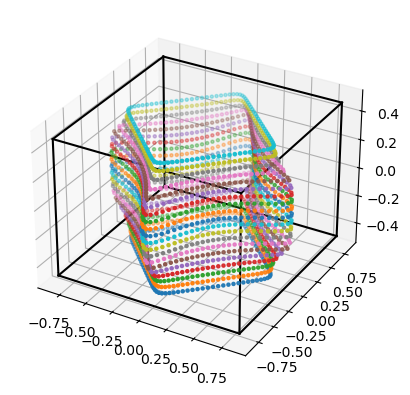

Time taken to create Fermi Surface = 0.06199336051940918


In [8]:
dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.134,T11multvalue=0.067,Tzmultvalue=0.105,mumultvalue=0.81)
FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
starttime = time()
FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
endtime = time()
FSorbitsInstance.plotpoints()
print(f"Time taken to create Fermi Surface = {endtime - starttime}")

In [ ]:
Tlist = [20,25,30,35]
paramslist = []

for temp in Tlist:
    filename = f"fit_logs_fixTz_at35K/fit_logs_24perc_{temp}K.txt"
    cost,Tzmultvalue,invtau_iso,invtau_aniso = np.loadtxt(filename,unpack=True,skiprows=5,delimiter=",")
    min_index = np.argmin(cost)
    paramslist.append((Tzmultvalue[min_index],invtau_iso[min_index],invtau_aniso[min_index]))
    print((Tzmultvalue[min_index],invtau_iso[min_index],invtau_aniso[min_index]))

rhozzlist0 = []
rhozzlist45 = []
data_rhozz0list = []
data_rhozz45list = []
data_theta0list = []
data_theta45list = []

for T,params in zip(Tlist,paramslist):

    #load data
    data_theta0,data_rhozz0 = np.loadtxt(f"data/2511A/2511A_phi0_T{T}K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta0list.append(data_theta0)
    data_rhozz0list.append(data_rhozz0)

    data_theta45,data_rhozz45 = np.loadtxt(f"data/2511A/2511A_phi45_T{T}K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta45list.append(data_theta45)
    data_rhozz45list.append(data_rhozz45)

    #generate data
    rhozzlist0.append(create_rhozz(phi=0,Bmag=45,params=params))
    rhozzlist45.append(create_rhozz(phi=45,Bmag=45,params=params))

(np.float64(0.10491361694456552), np.float64(11.614784992215412), np.float64(243.82469315042206))
(np.float64(0.10491361694456552), np.float64(13.11690604530813), np.float64(248.31424942487095))
(np.float64(0.10491361694456552), np.float64(14.071560328162724), np.float64(257.6044644433254))
(np.float64(0.10493178702494892), np.float64(15.20125224252804), np.float64(264.51855711483523))
Time taken to create Fermi Surface = 0.06246519088745117. Doping = 0.24305990174334824%
Time taken to create B independent Amatrix =  0.004600048065185547
Time taken to create Fermi Surface = 0.09384989738464355. Doping = 0.24305990174334824%
Time taken to create B independent Amatrix =  0.006390571594238281
Time taken to create Fermi Surface = 0.05834555625915527. Doping = 0.24305990174334824%
Time taken to create B independent Amatrix =  0.007291555404663086
Time taken to create Fermi Surface = 0.06329131126403809. Doping = 0.24305990174334824%
Time taken to create B independent Amatrix =  0.0054280757

<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not w

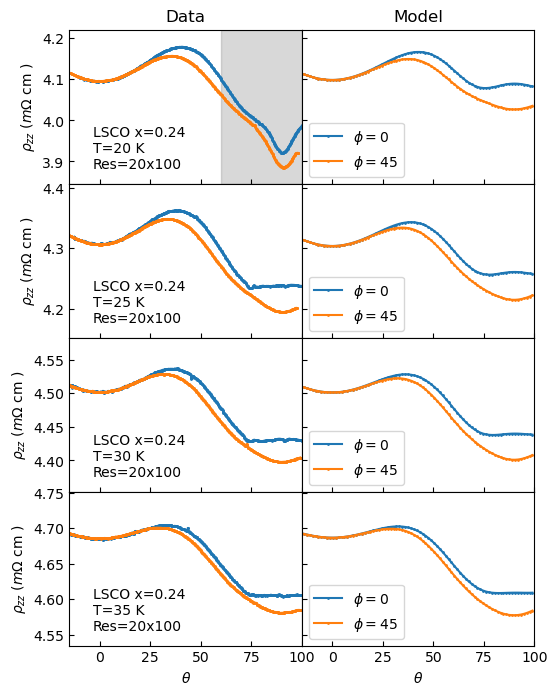

In [10]:
fig,axes = plt.subplots(nrows=4,ncols=2,figsize=(6,8),sharex=True)

for T,row,params,data_theta0,data_theta45,data_rhozz0,data_rhozz45,rhozz0,rhozz45 in zip(Tlist,axes,paramslist,data_theta0list,data_theta45list,data_rhozz0list,data_rhozz45list,rhozzlist0,rhozzlist45):

    row[1].plot(thetalist,rhozz0,ls="-",marker="o",ms=1,label=f"$\phi=0$")
    row[1].plot(thetalist,rhozz45,ls="-",marker="o",ms=1,label=f"$\phi=45$")
    row[0].plot(data_theta0,data_rhozz0,ls="-",marker="o",ms=1,label=f"$\phi=0$")
    row[0].plot(data_theta45,data_rhozz45,ls="-",marker="o",ms=1,label=f"$\phi=45$")
    row[0].set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )")
    row[0].text(0.1,0.1,f"LSCO x=0.24\nT={T} K\nRes={res_z}x{res_xy}",fontsize=10, transform=row[0].transAxes)
    row[1].legend()
    row[1].set_yticklabels([])

    for column in row:
        column.set_ylim(np.min(data_rhozz45)*0.99,np.max(data_rhozz0)*1.01)
        column.tick_params(direction='in')

axes[3,0].set_xlabel(r'$\theta$')
axes[3,1].set_xlabel(r'$\theta$')
axes[0,0].set_title("Data")
axes[0,1].set_title("Model")

axes[0,0].axvspan(60, 120, alpha=0.3, color='gray')
axes[0,0].set_xlim(-15,100)

#make vspace 0
plt.subplots_adjust(hspace=0.0,wspace=0.0)

plt.show()

Text(0.1, 0.8, 'LSCO x=0.24\nRes=20x100')

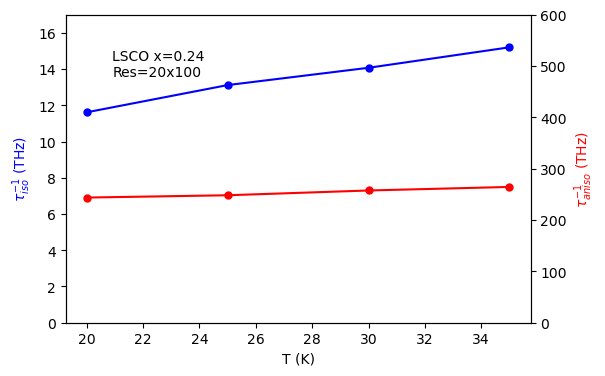

In [11]:
#plotting scattering rates
fig,axes = plt.subplots(figsize=(6,4))
axes2 = axes.twinx()

invtau_iso_list = [params[1] for params in paramslist]
invtau_aniso_list = [params[2] for params in paramslist]

axes.plot(Tlist,invtau_iso_list,ls="-",marker="o",ms=5,label=r"$\tau_{iso}^{-1}$",color="blue")
axes.set_ylabel(r"$\tau_{iso}^{-1}$ (THz)",color="blue")
axes.set_ylim(0,17)

axes2.plot(Tlist,invtau_aniso_list,ls="-",marker="o",ms=5,label=r"$\tau_{aniso}^{-1}$",color="red")
axes2.set_ylabel(r"$\tau_{aniso}^{-1}$ (THz)",color="red")
axes.set_xlabel("T (K)")
axes2.set_ylim(0,600)

axes.text(0.1,0.8,f"LSCO x=0.24\nRes={res_z}x{res_xy}",fontsize=10, transform=axes.transAxes)

[np.float64(22.516191733173564), np.float64(25.106348618035078), np.float64(26.822329163525264), np.float64(28.794398663657958)]


Text(0.1, 0.8, 'LSCO x=0.24\nRes=20x100')

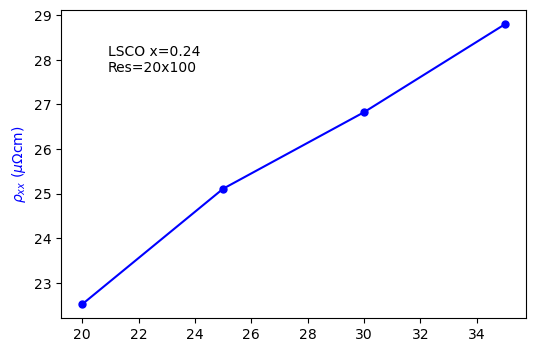

In [24]:
#plotting rhoxx
fig,axes = plt.subplots(figsize=(6,4))

rhoxx_list = [calc_rhoxx_zeroB(params)*1e3 for params in paramslist]
print(rhoxx_list)

axes.plot(Tlist,rhoxx_list,ls="-",marker="o",ms=5,label=r"$\rho_{xx}$",color="blue")
axes.set_ylabel(r"$\rho_{xx}$ ($\mu\Omega$cm)",color="blue")

axes.text(0.1,0.8,f"LSCO x=0.24\nRes={res_z}x{res_xy}",fontsize=10, transform=axes.transAxes)